# Pooled Linear Probe Evaluation

In [1]:
import os
print(f"Current Directory: {os.getcwd()}")
os.chdir("..")
print(f"New Directory: {os.getcwd()}")

Current Directory: c:\Users\mattc\Documents\DL-reservoir-modeling\additional_experiments
New Directory: c:\Users\mattc\Documents\DL-reservoir-modeling


In [2]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch, PathPatch
import pandas as pd
import seaborn as sns

In [3]:
def plot_pooled_linear_probe(ax):
    # ----     Read and format data   ---- #
    results_dir = Path('report/results/additional_experiments/pooled_linear_probe')
    pooled_probe = pd.read_csv(results_dir / 'oos_pooled_linear_probe_correlation.csv', index_col=0)
    baseline_probe = pd.read_csv(results_dir / 'oos_baseline_linear_probe_correlation.csv', index_col=0)
    finetuned_probe = pd.read_csv(results_dir / 'oos_finetuned_pooled_linear_probe_correlation.csv', index_col=0)
    individual_probe_full = pd.read_csv(Path('report/results/resops_training/resops_unroll_models/cell_storage_correlations/cell_storage_corr_model1_test.csv'), index_col=0)

    oos_ids = pd.read_csv(Path('report/results/additional_experiments/hyperparameter_tuning_pooled/resops_oos_out_of_sample_test.csv'), index_col=0).index.astype(str).tolist()
    individual_probe = pd.to_numeric(individual_probe_full.iloc[-1][oos_ids], errors='coerce').dropna()

    year_order = [5, 10, 15, 20, 25, 30]
    hue_order = [
        'finetuned pooled | Layer 1',
        'finetuned pooled | Layer 2',
        'individual (horizon only) | Layer 1',
        'individual (horizon only) | Layer 2'
    ]
    records = []

    # Individual plain reference (one LSTM layer only)
    for value in individual_probe.values:
        records.append({
            'category': 'individual',
            'group': 'plain',
            'plot_group': 'plain',
            'layer': 'Layer 1',
            'value': value
        })

    # Pooled plain reference (two layers)
    for col in pooled_probe.columns:
        match = re.fullmatch(r'layer_(\d+)_pooled_corr', str(col))
        if not match:
            continue
        layer = f"Layer {int(match.group(1))}"
        for value in pd.to_numeric(pooled_probe[col], errors='coerce').dropna().values:
            records.append({
                'category': 'pooled',
                'group': 'plain',
                'plot_group': 'plain',
                'layer': layer,
                'value': value
            })

    # Horizon groups
    for df, prefix, group_label in [
        (finetuned_probe, 'finetuned_pooled', 'finetuned pooled'),
        (baseline_probe, 'baseline', 'individual (horizon only)')
    ]:
        for col in df.columns:
            match = re.fullmatch(rf'{prefix}_(\d+)yr_layer_(\d+)_corr', str(col))
            if not match:
                continue

            year = int(match.group(1))
            layer = f"Layer {int(match.group(2))}"
            plot_group = f'{group_label} | {layer}'

            for value in pd.to_numeric(df[col], errors='coerce').dropna().values:
                records.append({
                    'category': f"{year} yr\nhorizon",
                    'group': group_label,
                    'plot_group': plot_group,
                    'layer': layer,
                    'value': value
                })
    long_df = pd.DataFrame(records)
    cat_order = ['individual', 'pooled'] + [f"{year} yr\nhorizon" for year in year_order]
    plain_df = long_df[long_df['group'] == 'plain']
    non_plain = long_df[long_df['group'] != 'plain']

    # ----   Create grouped boxplot on ax ---- #

    palette = {
        'finetuned pooled | Layer 1': sns.color_palette()[0],
        'finetuned pooled | Layer 2': sns.color_palette()[0],
        'individual (horizon only) | Layer 1': sns.color_palette()[1],
        'individual (horizon only) | Layer 2': sns.color_palette()[1],
        'plain': 'lightgrey'
    }

    # Common outline settings
    common_kws = dict(linewidth=0.8, boxprops=dict(edgecolor='black'), whiskerprops=dict(color='black'), capprops=dict(color='black'),
        medianprops=dict(color='black'), flierprops=dict(markeredgecolor='black', markerfacecolor='none'))


    # 1) finetuned/baseline (dodged) using the original code pattern
    sns.boxplot(data=non_plain, x='category', y='value', hue='plot_group', palette=palette, hue_order=hue_order, order=cat_order, ax=ax, width=0.8, **common_kws)

    # Hatch Layer 2 so both layers can keep the original model colors.
    # Sort seaborn's actual box patches by horizontal position, then hatch
    # the 2nd and 4th boxes inside each 4-box horizon cluster.
    expected_non_plain_boxes = len(year_order) * len(hue_order)
    non_plain_boxes = [patch for patch in ax.patches if isinstance(patch, PathPatch)][:expected_non_plain_boxes]
    non_plain_boxes = sorted(non_plain_boxes, key=lambda patch: (patch.get_extents().x0 + patch.get_extents().x1) / 2)
    for start in range(0, len(non_plain_boxes), len(hue_order)):
        cluster = non_plain_boxes[start:start + len(hue_order)]
        if len(cluster) == len(hue_order):
            cluster[1].set_hatch('////')
            cluster[3].set_hatch('////')

    # 2) plain (centered) references, matching the original idea of adding plain boxes afterward
    individual_values = plain_df[(plain_df['category'] == 'individual') & (plain_df['layer'] == 'Layer 1')]['value'].dropna().values
    if len(individual_values) > 0:
        bp = ax.boxplot([individual_values], positions=[0], widths=0.4, patch_artist=True, manage_ticks=False,
                        boxprops=dict(edgecolor='black', linewidth=0.8), whiskerprops=dict(color='black', linewidth=0.8),
                        capprops=dict(color='black', linewidth=0.8), medianprops=dict(color='black', linewidth=0.8),
                        flierprops=dict(markeredgecolor='black', markerfacecolor='none'))
        for box in bp['boxes']:
            box.set_facecolor(palette['plain'])

    pooled_l1 = plain_df[(plain_df['category'] == 'pooled') & (plain_df['layer'] == 'Layer 1')]['value'].dropna().values
    pooled_l2 = plain_df[(plain_df['category'] == 'pooled') & (plain_df['layer'] == 'Layer 2')]['value'].dropna().values

    for values, pos, hatch in [(pooled_l1, 1 - 0.11, None), (pooled_l2, 1 + 0.11, '////')]:
        if len(values) == 0:
            continue
        bp = ax.boxplot([values], positions=[pos], widths=0.18, patch_artist=True, manage_ticks=False,
                        boxprops=dict(edgecolor='black', linewidth=0.8), whiskerprops=dict(color='black', linewidth=0.8),
                        capprops=dict(color='black', linewidth=0.8), medianprops=dict(color='black', linewidth=0.8),
                        flierprops=dict(markeredgecolor='black', markerfacecolor='none'))
        for box in bp['boxes']:
            box.set_facecolor(palette['plain'])
            if hatch is not None:
                box.set_hatch(hatch)


    handles, labels = ax.get_legend_handles_labels()
    model_handles = []
    model_labels = []
    seen = set()
    for handle, label in zip(handles, labels):
        model_label = label.split(' | ')[0]
        if model_label not in seen:
            seen.add(model_label)
            model_handles.append(handle)
            model_labels.append(model_label)

    layer_handles = [
        Patch(facecolor='white', edgecolor='black', label='LSTM layer 1'),
        Patch(facecolor='white', edgecolor='black', hatch='////', label='LSTM layer 2')
    ]

    ax.legend(model_handles + layer_handles, model_labels + ['LSTM layer 1', 'LSTM layer 2'], title=None)
    return

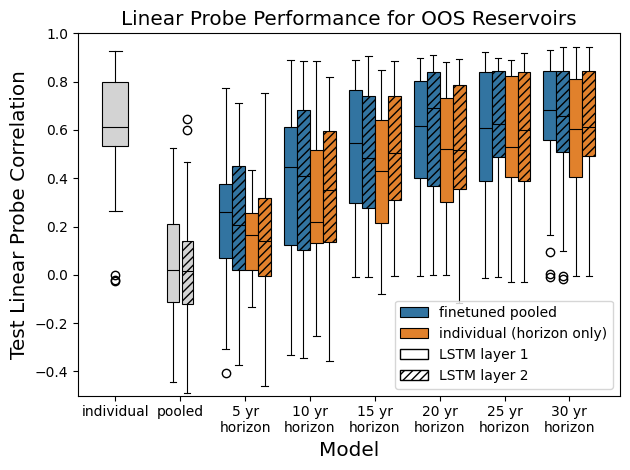

In [4]:
fig, ax = plt.subplots()
plot_pooled_linear_probe(ax)
ax.set_ylim(-0.5, 1)
ax.set_ylabel('Test Linear Probe Correlation', size='x-large')
ax.set_xlabel('Model', size='x-large')
ax.set_title('Linear Probe Performance for OOS Reservoirs', size='x-large')
plt.tight_layout()
plt.savefig('report/results/additional_experiments/pooled_linear_probe/finetuning_linear_probe.png', dpi=300)
plt.show()

## Combined figure with performance

In [5]:
def plot_pooled_performance(ax):
    # Read baseline data
    baseline_r2 = pd.read_csv('report/results/additional_experiments/hyperparameter_tuning_pooled/resops_oos_finetuning_baseline.csv', index_col=0)
    # Read finetuning data
    finetuning_r2 = pd.read_csv('report/results/additional_experiments/hyperparameter_tuning_pooled/resops_oos_finetuning.csv', index_col=0)

    def finetune_df_to_long(df: pd.DataFrame, group_label: str) -> pd.DataFrame:
        """
        Convert a wide df to long form with columns mapped to a 'category' (years)
        and rows as 'value'. Unmatched columns are skipped.
        """
        # Regex to find one of the years as a standalone number chunk (e.g. handles "finetuned_pooled_5yr")
        year_re = re.compile(r'(?<!\d)(5|10|15|20|25|30)(?!\d)')

        records = []
        for col in df.columns:
            # Build rows: each non-NA entry in this column becomes one record
            col_values = df[col].dropna()
            if len(col_values) == 0:
                continue

            m = year_re.search(str(col))
            if not m:
                category = col
                group = "plain"
            else:
                category = f"{int(m.group(0))} yr\nhorizon"
                group = group_label

            records.append(pd.DataFrame({
                "category": category,
                "group": group,
                "value": col_values.values
            }))
        return pd.concat(records, ignore_index=True) if records else pd.DataFrame(columns=["category", "group", "value"])

    # Build long-form from both sources
    long_finetune = finetune_df_to_long(finetuning_r2, "finetune")
    long_baseline = finetune_df_to_long(baseline_r2, "individual (horizon only)")
    long_df = pd.concat([long_finetune, long_baseline], ignore_index=True)

    palette = {
        "finetune": sns.color_palette()[0],
        "individual (horizon only)": sns.color_palette()[1],
        "plain": "lightgrey"
    }


    cat_order = list(pd.unique(long_df["category"])) # Desired category order
    plain_df = long_df[long_df["group"] == "plain"] # Split data: pooled and individual
    non_plain = long_df[long_df["group"] != "plain"] # Split data: finetune and baseline
    # Common outline settings
    common_kws = dict(linewidth=0.8, boxprops=dict(edgecolor="black"), whiskerprops=dict(color="black"), capprops=dict(color="black"),
        medianprops=dict(color="black"), flierprops=dict(markeredgecolor="black", markerfacecolor="none"))


    # 1) finetune/baseline (dodged)
    sns.boxplot(data=non_plain, x="category", y="value", hue="group", palette=palette, order=cat_order, ax=ax, width=0.8, **common_kws)
    # 2) plain (centered)
    if not plain_df.empty:
        sns.boxplot(data=plain_df, x="category", y="value", color=palette["plain"], order=cat_order, ax=ax, width=0.4, **common_kws)

    handles, labels = ax.get_legend_handles_labels()
    keep = [i for i, lab in enumerate(labels) if lab != "plain"]
    ax.legend([handles[i] for i in keep], [labels[i] for i in keep], title=None)

    return

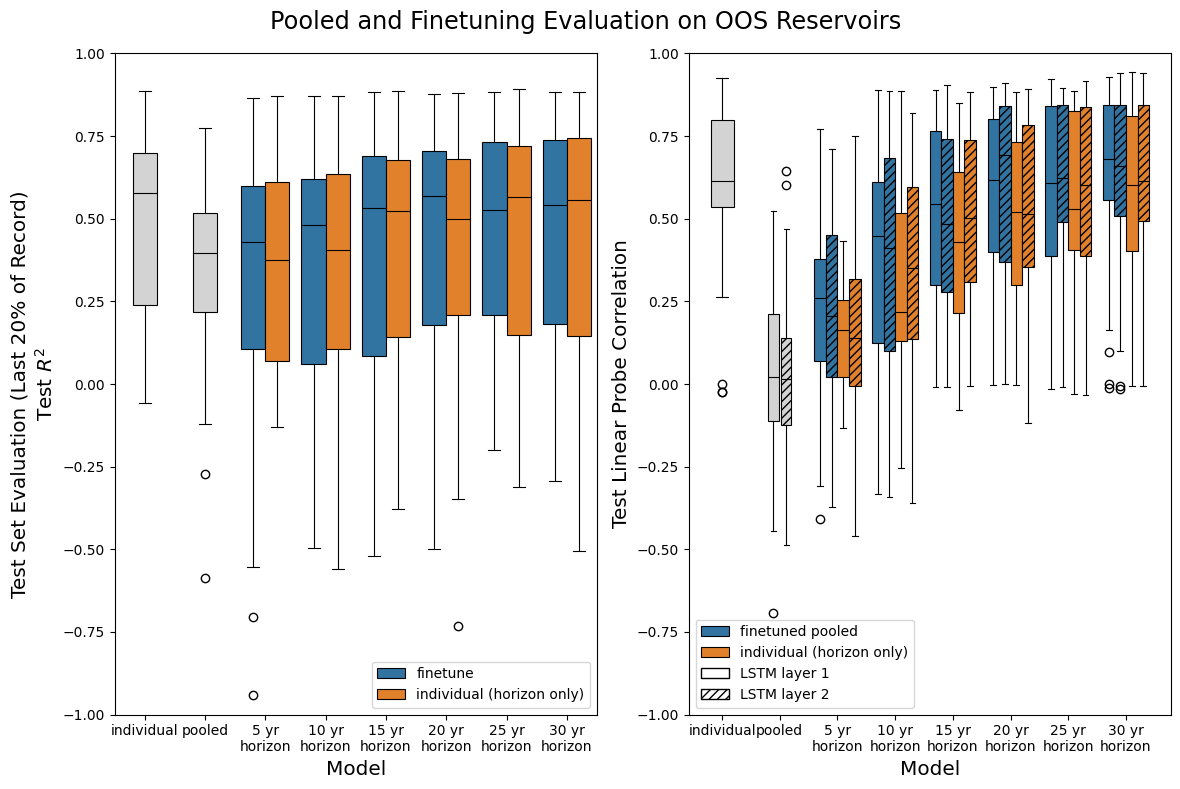

In [6]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 8))

plot_pooled_performance(axes[0])
axes[0].set_ylim(-1, 1)
axes[0].set_ylabel('Test $R^2$', size='x-large')
axes[0].set_xlabel('Model', size='x-large')

plot_pooled_linear_probe(axes[1])
axes[1].set_ylim(-1, 1)
axes[1].set_ylabel('Test Linear Probe Correlation', size='x-large')
axes[1].set_xlabel('Model', size='x-large')


fig.suptitle("Pooled and Finetuning Evaluation on OOS Reservoirs", size='xx-large')
fig.supylabel("Test Set Evaluation (Last 20% of Record)", size='x-large')
plt.tight_layout()
plt.savefig('report/results/additional_experiments/pooled_linear_probe/finetuning_combined_fig.png', dpi=300)
plt.show()